## Instalación de Dependencias
Ejecuta esta celda para instalar las librerías necesarias.

# Editor Node Implementation

Este notebook implementa el nodo "Editor" para el sistema de LangGraph especializado en música.
Incluye la definición del estado, herramientas para generar PDF y enviar correos, y la lógica del nodo.

In [1]:
# Importaciones originales del main.ipynb
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr

from langchain_cohere import ChatCohere
from pydantic import BaseModel
import random
from langchain_core.tools import Tool, StructuredTool
from langchain_community.utilities import GoogleSerperAPIWrapper

# Nuevas importaciones para el Editor Node
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders
from fpdf import FPDF
from typing import TypedDict, List, Dict, Any, Optional
import os

# Cargar variables de entorno
load_dotenv(override=True)

c:\Users\sabax\OneDrive\Desktop\Trabajo_IA\Trabajos_IA\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## 1. Definición del Estado (State)
Definimos la estructura `State` para manejar la información que fluye a través del grafo.

In [2]:
class State(TypedDict):
    concerts: List[Dict[str, Any]]  # Lista de conciertos
    suno_audio_url: str             # URL del audio generado por Suno
    formato_entrega: str            # 'email' o 'local'
    pdf_path: str                   # Ruta donde se guardó el PDF
    user_email: Optional[str]       # Email del usuario (opcional si es local)
    mp3_path: Optional[str]         # Ruta del archivo MP3 (opcional)
    # Otros campos que puedan existir en el grafo global...
    messages: Annotated[list, add_messages]

## 2. Herramienta PDF (FPDF2)
Función para generar el PDF con el diseño requerido.

In [3]:
def generate_pdf(concerts: List[Dict[str, Any]], suno_audio_url: str) -> str:
    """\n
    Genera un PDF utilizanod un LLM (Cohere) para escribir el contenido.\n
    La instrucción es: hacer una lista de los conciertos de la banda con los precios y luego poner la url de suno.\n
    """
    try:
        # Inicializar LLM
        llm = ChatCohere(temperature=0.5)
        
        # Crear prompt
        prompt = (
            f"Tienes que hacer una lista de los conciertos de la banda con los precios basándote en estos datos: {concerts}. "
            f"Y luego poner la url de suno: {suno_audio_url}. "
            f"IMPORTANTE: NO uses tablas de Markdown (con barras verticales '|'). "
            f"El output se escribirá directamente en un PDF simple. "
            f"Usa un formato de lista limpio y legible, por ejemplo:\n"
            f"- Fecha: [Fecha] en [Ciudad] - Precio: [Precio]. ([Link])\n"
            f"O usa párrafos elegantes. Agrega un título o introducción breve si queda bien."
        )
        
        # Invocar LLM
        response = llm.invoke(prompt)
        content = response.content
        
    except Exception as e:
        print(f"Error al llamar al LLM: {e}")
        content = f"Error generando contenido. Datos: {concerts}, URL: {suno_audio_url}"

    # Generar PDF con FPDF
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", size=12)

    # Título Genérico
    pdf.set_font("Arial", style="B", size=16)
    pdf.cell(0, 10, txt="Información de la Banda", ln=True, align='C')
    pdf.ln(10)
    # Cuerpo del texto generado por LLM
    pdf.set_font("Arial", size=12)
    # FPDF básico puede fallar con caracteres unicode no soportados en latin-1.
    # Reemplazamos caracteres problemáticos para evitar 'UnicodeEncodeError'.
    safe_content = content.encode('latin-1', 'replace').decode('latin-1')
    pdf.multi_cell(0, 10, txt=safe_content)
    output_filename = "conciertos_suno.pdf"
    pdf.output(output_filename)
    return os.path.abspath(output_filename)

from langchain_core.tools import tool

@tool
def generate_pdf_tool(concerts: List[Dict[str, Any]], suno_audio_url: str) -> str:
    """Genera el PDF con conciertos y link de audio usando LLM."""
    return generate_pdf(concerts, suno_audio_url)

## 3. Herramienta SMTP (Email)
Función para enviar el correo si el usuario lo solicita.

In [4]:
@tool
def send_email_tool(pdf_path: str, receiver_email: str, mp3_path: Optional[str] = None):
    """Envía el PDF generado y opcionalmente un MP3 por correo electrónico."""
    sender_email = os.getenv("EMAIL_SENDER")
    sender_password = os.getenv("EMAIL_PASSWORD")
    
    if not sender_email or not sender_password:
        print("Advertencia: No se han configurado EMAIL_SENDER o EMAIL_PASSWORD. No se envió el correo.")
        return "Error: Credenciales faltantes"

    msg = MIMEMultipart()
    msg['From'] = sender_email
    msg['To'] = receiver_email
    msg['Subject'] = "Tu Resumen de Conciertos y Música"

    body = "Adjunto encontrarás el PDF con la información de los conciertos y tu canción de Suno."
    msg.attach(MIMEText(body, 'plain'))

    # Adjuntar PDF
    try:
        filename = os.path.basename(pdf_path)
        with open(pdf_path, "rb") as attachment:
            part = MIMEBase("application", "octet-stream")
            part.set_payload(attachment.read())
        
        encoders.encode_base64(part)
        part.add_header(
            "Content-Disposition",
            f"attachment; filename= {filename}",
        )
        msg.attach(part)

        # Adjuntar MP3 si existe
        if mp3_path and os.path.exists(mp3_path):
            try:
                mp3_filename = os.path.basename(mp3_path)
                with open(mp3_path, "rb") as attachment:
                    part = MIMEBase("audio", "mpeg")
                    part.set_payload(attachment.read())
                
                encoders.encode_base64(part)
                part.add_header(
                    "Content-Disposition",
                    f"attachment; filename= {mp3_filename}",
                )
                msg.attach(part)
            except Exception as e:
                print(f"Error adjuntando MP3: {e}")

        server = smtplib.SMTP('smtp.gmail.com', 587)
        server.starttls()
        server.login(sender_email, sender_password)
        server.send_message(msg)
        server.quit()
        return "Correo enviado con éxito"
    except Exception as e:
        print(f"Error enviando correo: {e}")
        return f"Error enviando correo: {e}"

## 4. Lógica del Nodo Editor
El nodo que orquesta la generación y el envío.

In [5]:
def editor_node(state: State) -> State:
    """
    Nodo Editor: Genera PDF y gestiona el envío.
    """
    print("--- NODO EDITOR ---")
    
    # 1. Extraer datos
    concerts = state.get("concerts", [])
    suno_url = state.get("suno_audio_url", "")
    formato = state.get("formato_entrega", "local")
    email = state.get("user_email", "")
    mp3_path = state.get("mp3_path", None)

    # 2. Generar PDF
    # Llamamos a la lógica directamente o invocamos la tool si fuera un agente LLM.
    # Como es un nodo determinista, llamamos directo a la función subyacente o a la tool.
    pdf_file = generate_pdf(concerts, suno_url)
    
    # Actualizamos el path en el estado (temporalmente antes de retornar)
    state["pdf_path"] = pdf_file

    # 3. Evaluar condición de envío
    if formato == "email":
        if email:
            print(f"Enviando correo a {email}...")
            # Mock de envío o envío real
            result = send_email_tool.invoke({"pdf_path": pdf_file, "receiver_email": email, "mp3_path": mp3_path})
            print(f"Resultado envío: {result}")
        else:
            print("Se solicitó email pero no se proporcionó dirección. Guardado local.")
            print(f"Archivo guardado en local: {pdf_file}")
    else:
        print(f"Archivo guardado en local: {pdf_file}")

    return state

## 5. Verificación (Mock Run)
Probamos el nodo con datos falsos para verificar que funciona.

In [6]:
mock_state = {
    "concerts": [
        {"fecha": "2024-05-20", "ciudad": "Madrid", "precio": "50 EUR", "link": "http://ticket.com/1"},
        {"fecha": "2024-06-15", "ciudad": "Barcelona", "precio": "45 EUR", "link": "http://ticket.com/2"}
    ],
    "suno_audio_url": "https://suno.ai/song_123",
    "formato_entrega": "local", # Cambiar a 'email' para probar envío (requiere credenciales .env)
    "pdf_path": "",
    "user_email": "test@example.com",
    "mp3_path": "", # Ruta opcional al archivo MP3
    "messages": []
}

# Ejecutar nodo
final_state = editor_node(mock_state)

print("\nEstado Final:", final_state)

--- NODO EDITOR ---
Archivo guardado en local: c:\Users\sabax\OneDrive\Desktop\Trabajo_IA\Trabajos_IA\conciertos_suno.pdf

Estado Final: {'concerts': [{'fecha': '2024-05-20', 'ciudad': 'Madrid', 'precio': '50 EUR', 'link': 'http://ticket.com/1'}, {'fecha': '2024-06-15', 'ciudad': 'Barcelona', 'precio': '45 EUR', 'link': 'http://ticket.com/2'}], 'suno_audio_url': 'https://suno.ai/song_123', 'formato_entrega': 'local', 'pdf_path': 'c:\\Users\\sabax\\OneDrive\\Desktop\\Trabajo_IA\\Trabajos_IA\\conciertos_suno.pdf', 'user_email': 'test@example.com', 'mp3_path': '', 'messages': []}


C:\Users\sabax\AppData\Local\Temp\ipykernel_11528\455662630.py:32: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", size=12)
C:\Users\sabax\AppData\Local\Temp\ipykernel_11528\455662630.py:35: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", style="B", size=16)
C:\Users\sabax\AppData\Local\Temp\ipykernel_11528\455662630.py:36: DeprecationWarning: The parameter "txt" has been renamed to "text" in 2.7.6
  pdf.cell(0, 10, txt="Información de la Banda", ln=True, align='C')
C:\Users\sabax\AppData\Local\Temp\ipykernel_11528\455662630.py:36: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, txt="Información de la Banda", ln=True, align='C')
C:\Users\sabax\AppData\Local\Temp\ipykernel_11528\455662630.

Visualizando el grafo del nodo Editor...


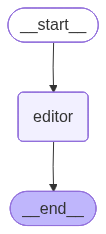

In [7]:
# Visualización del Grafo (Mock)
# Construimos un grafo simple para visualizar el nodo Editor conectado a START y END.
try:
    from langgraph.graph import StateGraph, START, END
    from IPython.display import Image, display

    # Construcción del grafo de prueba
    builder = StateGraph(State)
    builder.add_node("editor", editor_node)
    builder.add_edge(START, "editor")
    builder.add_edge("editor", END)

    # Compilación
    graph = builder.compile()

    # Visualización
    print("Visualizando el grafo del nodo Editor...")
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Error al generar imagen del grafo (¿tienes graphviz instalado?): {e}")
        # Intento alternativo texto
        print(graph.get_graph().draw_ascii())
except Exception as e:
    print(f"Error general en la visualización: {e}")